# **Step2_AI 강사 Agent v2.0**

## **0. 미션**

### **미션③ : 모듈 고도화1**
다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.

* 입력 프롬프트 추가 : 강의 목소리, 톤 조절, 강의 스타일 지침
* 정보 분해 : 여러 슬라이드를 저장하고 관리하기 위한 폴더 준비, 불필요한 정보 제거, 제목 추출
* 페이지별 내용 생성 : 슬라이드 내 정보 뿐만 아니라 부연 설명을 위한 검색 기능 추가
* 강의 스크립트 생성 : 전체 강의 내용을 참조하여 강의 흐름을 구상하고,
                                   현재 페이지 강의 스크립트 작성
* 내용 검토 : 페이지 내용과 강의 스크립트 비교, 강의 스크립트 흐름 적절한지 검토




### **미션④ : AI 강사 Agent 완성**
* 모듈 고도화2(다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.)
    * 음성 변환 : 강의 목소리, 톤 조절 음성 변환
    * 영상 제작 :
        * 각 페이지 : 음성과 슬라이드 스냅샷 이미지 합성하여 영상 제작하기
        * 전체 강의 영상 : 각 슬라이드 강의를 전체 슬라이드 강의 영상으로 합치기
* 웹 화면 연결(gradio)
    * 음성 변환 : 강의 목소리, 톤 조절 프롬프트 기반 음성 변환
* 전체 Agent 그래프 구축
    * 전체를 Agent 그래프로 엮기


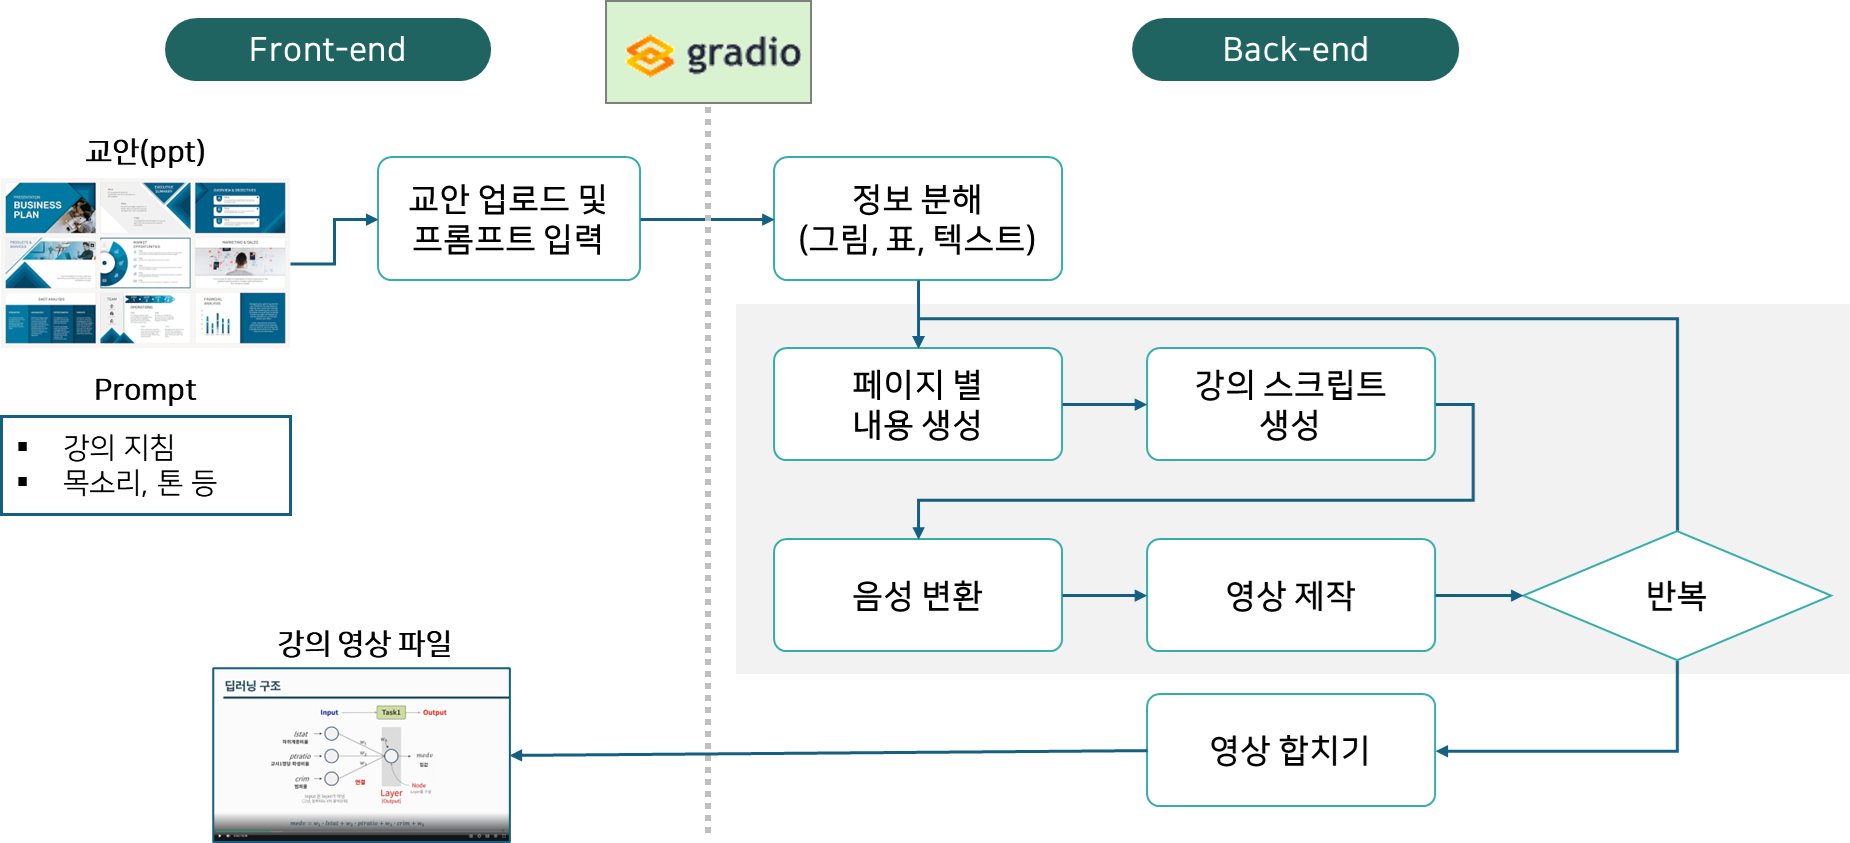

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
    * 새 폴더(project_multi_modal)를 생성하고
    * 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### (2) 한글 폰트 준비
* 한글 폰트 설치 및 설정 코드
* 영상 제작 등 한글 사용시 필요

In [ ]:
# @title
!apt-get -y install ffmpeg libreoffice poppler-utils poppler-data locales \
                   fonts-noto-cjk fonts-noto-cjk-extra fonts-nanum fonts-unfonts-core
!sed -i 's/^# *ko_KR.UTF-8 UTF-8/ko_KR.UTF-8 UTF-8/' /etc/locale.gen
!locale-gen ko_KR.UTF-8
!update-locale LANG=ko_KR.UTF-8
!fc-cache -fv

In [ ]:
# @title
%%bash
mkdir -p ~/.config/fontconfig
cat > ~/.config/fontconfig/fonts.conf <<'EOF'
<?xml version="1.0"?>
<!DOCTYPE fontconfig SYSTEM "fonts.dtd">
<fontconfig>

  <!-- ▷ 한국어 텍스트엔 Noto Sans CJK KR을 우선 사용 -->
  <match target="pattern">
    <test name="lang" compare="eq"><string>ko</string></test>
    <edit name="family" mode="prepend" binding="strong">
      <string>Noto Sans CJK KR</string>
    </edit>
  </match>

  <!-- ▷ 일반 가족명에도 기본 대체 추가 -->
  <alias><family>sans-serif</family><prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>serif</family><prefer><family>Noto Serif CJK KR</family></prefer></alias>
  <alias><family>monospace</family><prefer><family>Noto Sans Mono CJK KR</family></prefer></alias>

  <!-- ▷ Windows/macOS/웹에서 흔한 한글 폰트들을 Noto로 매핑 -->
  <alias><family>Malgun Gothic</family>        <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>맑은 고딕</family>             <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>Apple SD Gothic Neo</family>  <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>AppleGothic</family>          <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>Pretendard</family>           <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>Pretendard Variable</family>  <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>NanumSquare</family>          <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>Spoqa Han Sans</family>       <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>KoPub</family>                <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>Gulim</family>                <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>Dotum</family>                <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>Batang</family>               <prefer><family>Noto Serif CJK KR</family></prefer></alias>
</fontconfig>
EOF
fc-cache -fv


### (3) 라이브러리

* 필요한 라이브러리 설치

In [ ]:
# @title
!apt-get -y install ffmpeg libreoffice poppler-utils
!pip install python-pptx pillow langgraph google-search-results gradio -q

* 라이브러리 로딩

In [ ]:
import os, re, textwrap, subprocess, json, base64, mimetypes, shlex, requests, tempfile
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Optional, TypedDict, Any, Union
from PIL import Image, ImageDraw
from pptx import Presentation
from pptx.enum.shapes import MSO_SHAPE_TYPE
from openai import OpenAI
from google.colab import files
from IPython.display import Audio, display, Video

from serpapi import GoogleSearch

### (4) OpenAI API Key 확인
* 구글드라이브에 생성한 폴더 'project_multi_modal'에서
* api_key.txt 파일 안에 각자 발급 받은 키를 저장합니다.
    * **openai api key**
    * **SERPAPI_API_KEY**

In [ ]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/project_multi_modal/'
# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [ ]:
print(os.environ['OPENAI_API_KEY'][:30])
print(os.environ['SERPAPI_API_KEY'][:30])

### (5) 유용한 함수들 제공
* 다음은 프로젝트를 수행하는데 유용한 함수들입니다.
* 이 함수들의 내용을 확인하고 필요시 활용하여 개인 과제를 수행합니다.(꼭 활용해야 하는 것은 아닙니다.)

* 공백 제거 함수

In [ ]:
def clean_text(s):
    return re.sub(r"\s+", " ", s).strip()

* 긴 문자열을 문장 단위로 나누는 문장 분리기

In [ ]:
def split_sents(t: str) -> List[str]:
    parts = re.split(r'([\.?!])', t)
    merged = []
    for i in range(0, len(parts)-1, 2):
        sent = (parts[i] + parts[i+1]).strip()
        if sent: merged.append(sent)
    if len(parts) % 2 == 1 and parts[-1].strip():
        merged.append(parts[-1].strip())
    return [s for s in merged if s]

* 오디오 길이 계산

In [ ]:
def ffprobe_duration(path: str) -> float:
    out = subprocess.check_output([
        "ffprobe","-v","error","-show_entries","format=duration",
        "-of","default=noprint_wrappers=1:nokey=1", path]).decode().strip()
    return float(out)

* 이미지를 base64로 변환

In [ ]:
def img_to_data_url(path: str) -> str:
    mime = mimetypes.guess_type(path)[0] or "image/png"
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime};base64,{b64}"

* 배경 이미지와 오디오 합쳐서 MP4 영상 만들기

In [ ]:
def render_mp4(image_path: str, audio_path: str, out_mp4: str,
               width=1920, height=1080, ):

    dur = ffprobe_duration(audio_path)

    vf = (f"scale={width}:{height}:force_original_aspect_ratio=decrease,"
          f"pad={width}:{height}:(ow-iw)/2:(oh-ih)/2:color=black"  )

    # FFmpeg 명령
    cmd = ["ffmpeg", "-y",
            "-loop", "1", "-i", image_path,   # 정지 이미지 입력
            "-i", audio_path,                 # 오디오 입력
            "-t", str(dur),                   # 길이 = 오디오 길이
            "-vf", vf,                        # 비디오 필터
            "-c:v", "libx264", "-preset", "veryfast", "-crf", "20",
            "-c:a", "aac", "-b:a", "192k",
            "-pix_fmt", "yuv420p",
            "-movflags", "+faststart",        # 웹/브라우저 재생 친화
            out_mp4]
    subprocess.check_call(cmd)  # 외부 프로그램(FFmpeg)을 파이썬 프로세스에서 실행하고, 성공했는지 확인

* ppt 슬라이드를 배경 이미지로 저장
    * 강의 영상에서 사용할 배경 이미지 생성하기
    * ppt를 pdf로 변환한 뒤 다시 이미지로 변환

In [ ]:
# 슬라이드를 이미지로 저장
def export_slide_as_png(state: dict, dpi: int = 220) -> dict:
    work_dir = Path(state["work_dir"]).expanduser().resolve()
    work_dir.mkdir(parents=True, exist_ok=True)

    pptx = Path(state["pptx_path"]).expanduser().resolve()
    if not pptx.exists():
        raise FileNotFoundError(f"PPTX 없음: {pptx}")

    idx = int(state.get("slide_index", 0))  # 0-based
    page_no = idx + 1
    out_prefix = work_dir / "slide_img"

    # ▶ 폰트/로케일이 하위 프로세스에 확실히 전달되도록
    env = os.environ.copy()
    env.update({
        "LANG": "ko_KR.UTF-8",
        "LC_ALL": "ko_KR.UTF-8",
    })

    # --- A) 직접 PNG 변환 시도 (Impress filter) ---
    before_png = set(work_dir.glob("*.png"))
    png_cmd = [
        "soffice","--headless",
        "-env:UserInstallation=file:///tmp/lo_profile",
        "--convert-to", "png:impress_png_Export",
        "--outdir", str(work_dir),
        str(pptx),
    ]
    res_png = subprocess.run(png_cmd, capture_output=True, text=True, env=env)

    created_png = [p for p in work_dir.glob("*.png") if p not in before_png]
    # 페이지 번호가 붙는 경우가 있고, 아닌 경우도 있어 최신 파일 선택
    candidate = None
    exact = [p for p in created_png if p.stem.endswith(f"-{page_no}")]
    if exact:
        candidate = max(exact, key=lambda p: p.stat().st_mtime)
    elif created_png:
        candidate = max(created_png, key=lambda p: p.stat().st_mtime)

    if candidate and candidate.exists():
        state["slide_image"] = str(candidate)
        return state

    # --- B) 폴백: PDF → PNG  ---
    target_pdf = work_dir / f"{pptx.stem}.pdf"
    before_pdf = {p.name for p in work_dir.glob("*.pdf")}
    lo_cmd = [
        "soffice","--headless",
        "-env:UserInstallation=file:///tmp/lo_profile",
        "--convert-to","pdf:impress_pdf_Export",
        "--outdir", str(work_dir),
        str(pptx),
    ]
    res_pdf = subprocess.run(lo_cmd, capture_output=True, text=True, env=env)

    if target_pdf.exists():
        pdf_path = target_pdf
    else:
        created = [p for p in work_dir.glob("*.pdf") if p.name not in before_pdf]
        if created:
            pdf_path = max(created, key=lambda p: p.stat().st_mtime)
        else:
            print("LibreOffice 변환 실패")
            print("stdout:", res_pdf.stdout)
            print("stderr:", res_pdf.stderr)
            raise RuntimeError("PPTX → PDF 변환 실패")

    ppm_cmd = [
        "pdftoppm",
        "-f", str(page_no), "-l", str(page_no),
        "-png", "-r", str(dpi),
        str(pdf_path),
        str(out_prefix)
    ]
    res2 = subprocess.run(ppm_cmd, capture_output=True, text=True, env=env)
    png_path = Path(f"{out_prefix}-{page_no}.png")
    state["slide_image"] = str(png_path)
    return state

* 영상 합치기 : 여러 영상 경로를 리스트로 입력 받아 합치기

In [ ]:
def concat_videos_ffmpeg(video_paths: List[str], out_path: str, reencode: bool=False):
    list_path = out_path + ".txt"
    with open(list_path, "w", encoding="utf-8") as f:
        for v in video_paths:
            f.write(f"file '{os.path.abspath(v)}'\n")
    if reencode:
        cmd = [
            "ffmpeg","-y","-safe","0","-f","concat","-i",list_path,
            "-vf","format=yuv420p",
            "-c:v","libx264","-preset","veryfast",
            "-c:a","aac","-b:a","192k",
            out_path
        ]
    else:
        cmd = ["ffmpeg","-y","-safe","0","-f","concat","-i",list_path,"-c","copy",out_path]
    subprocess.check_call(cmd)

## **2. 미션③ : 모듈 고도화1**
(다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.)
* 입력 프롬프트 추가 : 강의 목소리, 톤 조절, 강의 스타일 지침
* 정보 분해 : 여러 슬라이드를 저장하고 관리하기 위한 폴더 준비, 불필요한 정보 제거, 제목 추출
* 페이지별 내용 생성 : 슬라이드 내 정보 뿐만 아니라 부연 설명을 위한 검색 기능 추가
* 강의 스크립트 생성 : 전체 강의 내용을 참조하여 강의 흐름을 구상하고,
                                   현재 페이지 강의 스크립트 작성
* 내용 검토 : 페이지 내용과 강의 스크립트 비교, 강의 스크립트 흐름 적절한지 검토

### (1) 파일 입력
* ppt 파일은 각 조에서 자체 준비
* 테스트용 샘플 ppt 제공 : sample2_test.pptx



In [ ]:
# 파일 업로드
uploaded = files.upload()
pptx_path = list(uploaded.keys())[0]

In [ ]:
# 사용자 프롬프트
USER_PROMPT = {
    "voice": "alloy",
    "tone": "친절하고 명료한 강의 톤",
    "style": "예시와 핵심 요점 중심"
}
# 출력 dir 만들기
WORK_DIR = "./step1_output"
MEDIA_DIR = "./step1_output/media"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(MEDIA_DIR, exist_ok=True)

### (2) State 선언

* 각 노드의 입출력 관리를 위한 State 구성
    * 각 함수(노드)에서 채워가며 관리해야 할 정보를 도출
    * 이를 하나의 State로 정의


In [ ]:
class State(TypedDict, total=False):
    # 입력/경로
    pptx_path: str
    work_dir: str

    # 진행 인덱스/메타
    slide_index: int
    total_slides: int
    DONE: bool

    # 🔴 반드시 포함: parse_all 산출물이 다음 노드로 이어지려면 필요
    slides: List[Dict[str, Any]]

    # 현재 슬라이드 파생 데이터
    title: str
    texts: List[str]
    tables: List[List[List[str]]]
    images: List[str]
    slide_image: Union[str, List[str]]
    snap_path: str

    # 생성 산출물
    page_content: str
    script: str
    audio: str
    video_path: str
    page_videos: List[str]
    final_video: str

    # 검색 결과
    search_title: str
    web_summary: str

In [ ]:
state = {
    "pptx_path": pptx_path,   # 너가 업로드한 PPT 파일 경로
    "work_dir": WORK_DIR,     # 미리 만든 작업 폴더
    "prompt": USER_PROMPT,    # 사용자 프롬프트(voice 등)
    "slide_index": 0,         # 1페이지 = 0번 슬라이드
}

### (3) 정보 분해
* 목적: 전체 슬라이드의 텍스트/표/이미지/스냅샷 수집 → state["slides"] 적재
* 입력: pptx_path, work_dir
* 출력: 슬라이드마다, text, image, text, 스냅(스크린샷) 등 저장
* 처리:
    * python-pptx로 텍스트/표/이미지 추출
    * 제목 추출
    * export_slide_as_png로 snap 생성

* 노드 함수 생성

In [ ]:
# (확인용 코드입니다.)
# (pptx 파일에서 제목이 몇번째 인덱스에 있는지 확인)
# -> 결과: 시작 슬라이드를 제외하고, 1번 인덱스에 제목이 위치하는 것을 확인하였음
# -> 텍스트가 1개만 존재하는 경우에 대해서는 그걸 제목을 추출하기로 결정 (그 외는 1번 인덱스)

from pptx import Presentation
import re

prs = Presentation(pptx_path)

for i, slide in enumerate(prs.slides):
    print("="*60)
    print(f" Slide {i+1}/{len(prs.slides)}")

    texts = []
    for j, sh in enumerate(slide.shapes):
        if sh.has_text_frame:
            txt = "\n".join(p.text for p in sh.text_frame.paragraphs)
            txt = clean_text(txt)
            if txt:
                texts.append(txt)
                print(f"  [{len(texts)-1}] {txt[:100]}{'...' if len(txt)>100 else ''}")


In [ ]:
def node_parse_all(state: State) -> State:
    """
    정보 분해 (고도화)
    - (step1) 슬라이드별로 텍스트 / 표 / 이미지 / 스냅샷 추출
    - (step2) 슬라이드 제목 추출 및 저장
    - (step2) 전체 슬라이드 반복 탐색
    """
    prs = Presentation(state["pptx_path"])
    work_dir = state.get("work_dir", "./output")
    media_dir = os.path.join(work_dir, "media")
    os.makedirs(media_dir, exist_ok=True)

    slides_info = []

    ##
    # 전체 슬라이드 탐색
    for idx, slide in enumerate(prs.slides):
        texts, tables, images = [], [], []

        # (1) 텍스트, 표, 이미지 추출
        for sh in slide.shapes:
            # 텍스트
            if sh.has_text_frame:
                txt = "\n".join(p.text for p in sh.text_frame.paragraphs)
                txt = clean_text(txt)
                if txt:
                    texts.append(txt)

            # 표
            if sh.shape_type == MSO_SHAPE_TYPE.TABLE:
                tbl = [
                    [clean_text(c.text) for c in r.cells]
                    for r in sh.table.rows
                ]
                tables.append(tbl)

            # 이미지
            if sh.shape_type == MSO_SHAPE_TYPE.PICTURE:
                img = sh.image
                ext = img.ext
                img_path = os.path.join(media_dir, f"slide{idx}_img_{len(images)}.{ext}")
                with open(img_path, "wb") as f:
                    f.write(img.blob)
                images.append(img_path)

        # (2) 제목 추출
        if len(texts) >= 2:
            title = texts[1]   # 텍스트가 2개 이상일 때 1번 인덱스 사용
        elif len(texts) == 1:
            title = texts[0]   # 텍스트가 1개뿐이면 0번 인덱스 사용
        else:
            title = "" #텍스트가 존재하지 않는 슬라이드임.

        # (3) 슬라이드 스냅샷 생성
        temp_state = state.copy()
        temp_state["slide_index"] = idx
        temp_state = export_slide_as_png(temp_state, dpi=220) #제공 함수 사용하였음
        snap_path = temp_state.get("slide_image", "")

        # (4) 슬라이드 정보
        slide_dict = {
            "index": idx,
            "title": title, #슬라이드 제목
            "texts": texts,
            "tables": tables,
            "images": images,
            "snap_path": snap_path, #스냅샷 경로
        }
        slides_info.append(slide_dict)

        print(f"Slide {idx+1}/{len(prs.slides)} 분석 완료 "
              f"(텍스트 {len(texts)}, 표 {len(tables)}, 이미지 {len(images)})")
    ##

    # (5) 전체 결과 state에 저장
    state["slides"] = slides_info
    state["_slides_backup"] = slides_info      # ✅ 백업 저장 (복구용)
    state["total_slides"] = len(state.get("slides", []))
    if int(state.get("slide_index", 0)) >= state["total_slides"]:
        state["slide_index"] = 0
    return state

* 노드 테스트

In [ ]:
WORK_DIR = "./step2_output"
os.makedirs(WORK_DIR, exist_ok=True)

state = {
    "pptx_path": pptx_path,
    "work_dir": WORK_DIR
}

state = node_parse_all(state)

# 슬라이드별 결과 출력
for s in state["slides"]:
    print("="*60)
    print(f"슬라이드 {s['index']+1}")
    print(f"제목: {s['title']}")
    print(f"텍스트 수: {len(s['texts'])}, 표 수: {len(s['tables'])}, 이미지 수: {len(s['images'])}")
    print(f"스냅샷 경로: {s['snap_path']}")

In [ ]:
# 확인용 코드
#(슬라이드 제목 - 스냅샷 이미지) 제대로 생성 되었는가 확인용 코드
from IPython.display import Image, display
import os

for slide in state["slides"]:
    snap_path = slide.get("snap_path")
    if snap_path and os.path.exists(snap_path):
        print(f"슬라이드 {slide['index']+1}: {slide['title']}")
        display(Image(filename=snap_path))  # ✅ open() 아님, filename= 로 전달
    else:
        print(f"[X] 슬라이드 {slide['index']+1} – 스냅샷 파일 없음 ({snap_path})")


### (4) 페이지별 내용 생성

* 목적: 슬라이드 내용을 text로 정리
* 입력 : text, image, 표, 슬라이드 제목
* 출력 : 슬라이드 설명문
* 처리
    * 슬라이드 제목으로 SerpAPI 검색 및 요약
    * text, image, 표에 대한 설명문 생성
    * 전체 설명문 작성

#### **1) 외부 검색 노드**


In [ ]:
def serpapi_search_by_title(title: str, num: int = 4) -> str:
    """
    슬라이드 '제목'을 키워드로 SerpAPI(google) 검색.
    - 환경변수 SERPAPI_KEY 가 없으면 검색을 생략하고 안내 문자열을 반환.
    - 상위 num개의 결과에서 title / snippet / link를 간단히 묶어 문자열로 돌려줌.
    """
    title = (title or "").strip()
    if not title:
        return "(검색 키워드가 비어 있어 외부 검색을 생략합니다.)"

    api_key = os.getenv("SERPAPI_API_KEY")
    if not api_key:
        return "(SERPAPI_API_KEY가 설정되지 않아 외부 검색을 생략합니다.)"

    try:
        params = {
            "engine": "google",
            "q": title,
            "hl": "ko",
            "gl": "kr",
            "num": max(1, min(int(num), 10)),
            "api_key": api_key,
        }
        r = requests.get("https://serpapi.com/search.json", params=params, timeout=15)
        r.raise_for_status()
        data = r.json()

        items = data.get("organic_results", [])[:params["num"]]
        if not items:
            return "(검색 결과가 없습니다.)"

        lines = []
        for it in items:
            t = (it.get("title") or "").strip()
            s = (it.get("snippet") or it.get("about_this_result", {}).get("source", "") or "").strip()
            l = (it.get("link") or "").strip()
            # 너무 길면 살짝 자르기
            s = textwrap.shorten(s, width=180, placeholder="…")
            lines.append(f"- {t}\n  요약: {s}\n  링크: {l}")

        out = "【외부 검색 요약】\n" + "\n".join(lines)
        # 프롬프트에 넣기 좋게 전체 길이 제한
        return textwrap.shorten(out, width=1200, placeholder=" …(생략)")
    except Exception as e:
        return f"(SerpAPI 호출 중 예외 발생: {type(e).__name__}: {e})"

def node_tool_search(state: dict) -> dict:
    """
    state['slides']에서 현재 slide_index 슬라이드를 골라
    해당 슬라이드의 제목으로 외부 검색을 수행.
    결과 요약은 state['web_summary']에 저장.
    """
    slides = state.get("slides", [])
    idx = state.get("slide_index", 0)

    if not slides:
        state["web_summary"] = "(slides가 비어 있음)"
        state["search_title"] = ""
        return state

    cur = slides[idx]  # 현재 슬라이드
    title = (cur.get("title") or "").strip()

    if not title:
        texts = cur.get("texts", []) or []
        if texts:
            first = (texts[0] or "").strip()
            title = first.splitlines()[0].strip() if first else ""
        if not title:
            joined = "\n".join(texts).strip()
            title = joined.splitlines()[0].strip() if joined else ""

    summary = serpapi_search_by_title(title, num=4)

    state["search_title"] = title
    state["web_summary"] = summary

    return state

In [ ]:
# 예) 파이프라인 중간
state = node_parse_all(state)          # 텍스트/표/이미지 추출
state = node_tool_search(state)        # ← 외부 검색 요약 적재
print(state["search_title"])
print(state["web_summary"])

#### **2) 내용 생성 함수**

In [ ]:
LLM_MODEL = "gpt-4o-mini"
TTS_MODEL = "gpt-4o-mini-tts"

In [ ]:
def node_generate_page_content(state: State) -> State:
    client = OpenAI()

    # --- 인덱스/경계 보정 ---
    idx = int(state.get("slide_index", 0))
    slides = state.get("slides") or []
    if not slides:
        print("[오류] slides 비어 있음");
        return state
    if idx < 0 or idx >= len(slides):
        print(f"[경고] slide_index {idx} → 0으로 보정 (총 {len(slides)}장)")
        idx = 0
        state["slide_index"] = 0

    cur = slides[idx]

    # --- 제목/본문 재구성 ---
    slide_title = (cur.get("title") or "").strip()
    texts  = cur.get("texts", []) or []
    tables = cur.get("tables", []) or []
    images = cur.get("images", []) or []

    if not slide_title and texts:
        slide_title = (texts[0] or "").splitlines()[0].strip()

    text_content = "\n".join(texts) or "(텍스트 없음)"
    table_txt = ""
    if tables:
        rows = tables[0][:6]
        table_txt = "\n".join(" | ".join(r) for r in rows)

    # --- 웹 요약/검색 키워드 보조 ---
    query = slide_title or state.get("search_title", "")
    serp_summary = ""
    try:
        search = GoogleSearch({
            "engine":"google","q":query,"hl":"ko","gl":"kr","num":5,
            "api_key": os.getenv("SERPAPI_API_KEY") or os.getenv("SERPAPI_KEY")
        })
        res = search.get_dict()
        organic = res.get("organic_results", []) or []
        if organic:
            serp_summary = "\n".join([r.get("snippet","") for r in organic[:3] if r.get("snippet")])
        else:
            serp_summary = "(검색결과 없음)"
    except Exception as e:
        print("⚠️ SerpAPI 검색 실패:", e)
        serp_summary = "(검색결과 없음)"

    # 이미지 블록 생성 (LLM multimodal 입력용)
    img_blocks = []
    if images:  # ← images는 slides[idx]에서 이미 가져온 리스트
        for img_path in images[:3]:  # 이미지가 너무 많으면 3장만 전달
            if os.path.exists(img_path):
                img_blocks.append({
                    "type": "image_url",
                    "image_url": {"url": img_to_data_url(img_path)}
                })

    system_prompt = (
        "당신은 강의 슬라이드를 설명하는 보조 AI입니다.\n"
        "1. 4~6문장, 과장 금지\n2. 불릿 금지\n3. 발표용 문단\n"
        "4. 표/이미지 핵심 포함\n5. 검색결과로 배경지식 1~2문장 보강"
    )
    user_prompt = (
        f"슬라이드 제목(또는 검색어): {slide_title}\n\n"
        f"검색결과 요약:\n{serp_summary}\n\n"
        f"텍스트 내용:\n{text_content}\n\n"
        f"표 내용:\n{table_txt}\n\n"
        f"이 내용을 바탕으로 발표용 설명문을 작성하세요."
    )

    messages = [
        {"role":"system","content":[{"type":"text","text":system_prompt}]},
        {"role":"user","content":[{"type":"text","text":user_prompt}, *img_blocks]}
    ]
    resp = client.chat.completions.create(
    model=LLM_MODEL, messages=messages, temperature=0.6, max_tokens=600
    )
    page_content = resp.choices[0].message.content.strip()
    page_content = (
        f"제목: {slide_title or '(제목 없음)'}\n\n"
        f"설명문 요약:\n{page_content}\n\n"
        f"텍스트 개요:\n{text_content[:1200]}\n\n"
        f"표 개요:\n{table_txt}\n\n"
        f"검색 쿼리: {query}\n"
    )

    # --- 저장: 슬라이드 & state 모두에 기록 ---
    cur["page_content"] = page_content       # ← 슬라이드에 저장 (중요)
    state["page_content"] = page_content     # ← state에도 복사 (호환)
    return state

* 노드 테스트

In [ ]:
slides = state["slides"]

# 슬라이드별로 인덱스를 지정해 호출
for i in range(len(state["slides"])):
    state["slide_index"] = i
    state = node_generate_page_content(state)   # ✅ state를 넘김
    cur = state["slides"][i]
    print(f"[생성 완료] Slide {i+1}: {cur.get('title')}")
    print(f"[설명문 요약]\n{(cur.get('page_content') or '')[:400]}...\n")

### (5) 강의 스크립트 생성

* 목적 : 슬라이드 요약(page_content)을 기반으로 60~90초 분량의 발표 대본(스크립트)을 작성하고 저장
* 입력:
    * 슬라이드 설명문
    * tone, 말투 지시 프롬프트
    * 스크립트 저장 디렉토리
    * 이전 페이지의 강의 스크립트(맥락/흐름 파악용)
* 출력: 생성된 발표 스크립트

* 노드 함수 생성

In [ ]:
def node_generate_script_with_context(state: State) -> State:
    # 인덱스/슬라이드 참조
    idx = state.get("slide_index", 0)
    slides = state.get("slides", [])

    # ✅ 방어: slides 비어있음/범위 초과 처리
    if not slides:
        print("    [건너뛰기] slides가 비어 있어 스크립트 생성을 생략합니다.")
        state["script"] = ""
        return state
    if idx < 0 or idx >= len(slides):
        print(f"    [경고] slide_index {idx} 범위 초과 → 0으로 보정 (총 {len(slides)}장)")
        idx = 0
        state["slide_index"] = 0

    cur = slides[idx]

    total_slides = state.get("total_slides", len(slides))
    print(f"    [4/4] 'node_generate_script' (Slide {idx+1}/{total_slides}) 실행...")

    # ✅ 요약 텍스트는 '현재 슬라이드'에서 가져오기
    current_summary = (
        cur.get("page_content")              # 우선순위 1: 요약문
        or cur.get("speaker_notes")          # 우선순위 2: 노트
        or cur.get("title", "")              # 우선순위 3: 제목(최후)
    ).strip()

    # ✅ 누적 스크립트 리스트/이전 스크립트 기본값 미리 준비 (fallback에서도 사용)
    all_scripts_list = state.get("all_scripts", [])
    previous_script = ""

     # ================== [추가] 짧은 슬라이드 즉시 스킵 ==================
    _title = (cur.get("title") or "").strip()
    _notes = (cur.get("speaker_notes") or "").strip()
    _content_raw = (cur.get("page_content") or "").strip()
    _texts = [str(t).strip() for t in (cur.get("texts") or []) if str(t).strip()]

    texts_join = " ".join(_texts).strip()

    def _wc(s: str) -> int:
        return len(s.split())

    # page_content가 제목/텍스트와 같거나, 6단어 이하인 경우는 '유효 내용 없음'으로 간주
    _content_is_trivial = (
        not _content_raw
        or (_title and _content_raw.lower() == _title.lower())
        or (texts_join and _content_raw.lower() == texts_join.lower())
        or _wc(_content_raw) <= 6
    )
    _content = "" if _content_is_trivial else _content_raw

    _title_l = _title.lower()
    _texts_join_l = texts_join.lower()

    _is_title_only = bool(_title) and not _texts and not _notes and not _content
    _is_agenda = any(k in _title_l for k in ("목차", "차례", "agenda", "contents")) \
                and len(_texts) <= 5 and all(len(t) < 20 for t in _texts)
    _is_thanks = any(k in _title_l for k in ("감사합니다", "thank you", "q&a", "질의응답")) \
                or any(k in _texts_join_l for k in ("감사합니다", "thank you", "q&a", "질의응답"))
    _is_minimal_info = (
        _wc(_title) <= 5 and not _notes and _wc(texts_join) <= 6 and not _content
    )
    _is_one_short_line = (len(_texts) <= 1) and (not _texts or len(_texts[0]) < 20) and not _notes and not _content

    _is_short_slide = _is_title_only or _is_agenda or _is_thanks or _is_minimal_info

    if _is_short_slide:
        if idx == 0 and _title:
            gen_script = f"안녕하세요. 오늘은 {_title}에 대해 간단히 소개하겠습니다."
        else:
            gen_script = _title if _title else "감사합니다."

        if idx == total_slides - 1 and "감사합니다" not in gen_script:
            gen_script += "\n경청해주셔서 감사합니다."

        cur["script"] = gen_script
        state["script"] = gen_script
        all_scripts_list.append(gen_script)
        state["all_scripts"] = all_scripts_list

        work_dir = state.get("work_dir", "./outputs")
        os.makedirs(work_dir, exist_ok=True)
        script_dir = os.path.join(work_dir, "scripts")
        os.makedirs(script_dir, exist_ok=True)
        script_path = os.path.join(script_dir, f"script_{idx+1:02d}.txt")
        with open(script_path, "w", encoding="utf-8") as f:
            f.write(gen_script)

        print("    [스킵] 짧은/제목형 슬라이드로 판단되어 간단 멘트 후 넘어갑니다.")
        return state
    # =====================================================================

     # ================== [추가] 자기소개 슬라이드 감지 & 검색 금지 ==================
    _joined_texts = " ".join(_texts)
    _haystack = f"{_title} {_joined_texts}".lower()
    _is_intro = any(key in _haystack for key in ("자기소개", "소개", "about me", "profile", "프로필", "이력", "경력"))

    if _is_intro:
        state["ban_search"] = True  # 그래프의 검색 노드가 이 플래그를 보고 SerpAPI를 생략하도록
    # =====================================================================

    if not current_summary or current_summary.startswith("[API"):
        # ✅ return 하지 말고 즉석 스크립트 생성으로 대체 (fallback)
        title = (cur.get("title") or "").strip()
        texts = cur.get("texts") or []
        bullets = "\n".join(f"- {t}" for t in texts[:5]) or "- 내용 요약 없음"
        gen_script = f"{title}\n\n{bullets}"

        # ✅ 마지막 슬라이드 후처리 (fallback에도 적용)
        if idx == total_slides - 1:
            import re
            gen_script = re.sub(r"(?:\s|\n)*(다음은[^.\n]*\.)\s*$", "", gen_script).strip()
            if not (gen_script.endswith("경청해주셔서 감사합니다.") or gen_script.endswith("경청해 주셔서 감사합니다.")):
                gen_script += "\n경청해주셔서 감사합니다."

        # 저장/상태 반영
        cur["script"] = gen_script
        state["script"] = gen_script
        all_scripts_list.append(gen_script)
        state["all_scripts"] = all_scripts_list

        # 저장(선택) — 기존 로직 재사용
        work_dir = state.get("work_dir", "./outputs")
        os.makedirs(work_dir, exist_ok=True)
        script_dir = os.path.join(work_dir, "scripts")
        os.makedirs(script_dir, exist_ok=True)
        script_path = os.path.join(script_dir, f"script_{idx+1:02d}.txt")
        with open(script_path, "w", encoding="utf-8") as f:
            f.write(gen_script)

        print("    [대체] 요약이 비정상이어서 fallback 스크립트로 대체했습니다.")
        return state

    # 톤/스타일
    user_prompt = state.get("prompt", {})
    user_tone  = user_prompt.get("tone",  "친절하고 명료한 강의 톤")
    user_style = user_prompt.get("style", "예시와 핵심 요점 중심")

    # 슬라이드 위치 기반 스타일 규칙 추가
    style_rules = []
    if idx == 0:
        style_rules += [
            "첫 문장은 반드시 '안녕하세요.'로 시작하고, 이어 '오늘은 [주제명]에 대해 발표하도록 하겠습니다.' 형식의 인사 문장으로 시작하라. 예시: '안녕하세요. 오늘은 머신러닝 모델의 성능 모니터링에 대해 발표하도록 하겠습니다.'",
            "그 다음 문장부터 본론을 자연스럽게 이어가라. 진행자 멘트('이번 슬라이드에서는', '이제')로는 시작하지 말 것."
        ]
    else:
        style_rules += [
            "인사/서론 금지. 절대 '안녕하세요', '여러분', '이번 슬라이드에서는', '이제'로 시작하지 말라.",
            "바로 핵심 문장으로 시작하라."
        ]
    if idx == total_slides - 1:
        style_rules += ["마지막 문단에만 1문장 마무리 인사 허용. 그 외에서는 금지."]

    style_rules_text = "\n    - " + "\n    - ".join(style_rules)
    style_rules_text += "\n    - 출력 첫 문장은 인사/메타 멘트 금지(중간·마지막 슬라이드). 즉시 핵심 문장으로 시작."

    # ✅ 연결 문장 규칙을 위치별로 분기
    if idx == 0:
        connector_rule = "첫 슬라이드: 마지막 문장에 다음 슬라이드로 넘어가는 '연결 문장'을 1개 포함하되, 반드시 다음 슬라이드 제목을 정확히 언급하라."
    elif idx == total_slides - 1:
        connector_rule = "마지막 슬라이드: 연결 문장 절대 금지. 마지막 문단은 '경청해주셔서 감사합니다.'로 품위 있게 마무리하라."
    else:
        connector_rule = "중간 슬라이드: 마지막 문장에 다음 슬라이드로 넘어가는 '연결 문장'을 1개 포함하되, 반드시 다음 슬라이드 제목을 정확히 언급하라."

    # 시스템 프롬프트
    sys_prompt = f"""
    당신은 청중을 사로잡는 전문 강사입니다.
    {style_rules_text}
    당신의 임무는 [이전 스크립트]의 흐름을 이어받아, [이번 요약]의 내용을 설명하는
    60~90초 분량의 매끄럽고 풍부한 강의 스크립트를 작성하는 것입니다.

    [강의 스타일 지침]
    1. 전체 톤: {user_tone}
    2. 전달 방식: {user_style} (단순 나열 X, 핵심-예시 중심)
    3. 어려운 개념은 짧은 비유/예시 포함
    4. {connector_rule}
    5. 금지: 불릿(•,-), 번호(1.), 과장된 감탄사, 구어체
    6. 허용: 전문적·명료·설득적 문어체 (~입니다/합니다)
    """.strip()

    if _is_intro:
        sys_prompt += (
            "\n\n[검색/지식 제한]\n"
            "- 외부 지식/인터넷/SerpAPI를 절대 사용하지 말 것.\n"
            "- 오직 슬라이드의 제목/텍스트/노트에 적힌 정보만 사용하여 간단히 소개하고 넘어갈 것.\n"
            "- 길게 서술하지 말고 2~4문장 이내로 끝낼 것.\n"
            "- 생년월일, 국적, 직업 등 추측/추가 정보 금지."
        )

    # 위치별 특수 지시
    if idx == 0:
        print("    [정보] 첫 번째 슬라이드입니다. 인삿말을 '포함'하도록 요청합니다.")
        previous_script = "(이전 스크립트 없음)"
        sys_prompt += (
            "\n\n[특별 지시: 첫 슬라이드]\n"
            "1) 첫 문장은 반드시 '안녕하세요.'로 시작하고, "
            "이어 '오늘은 [주제명]에 대해 발표하도록 하겠습니다.' 형식의 인사 문장으로 시작하라.\n"
            "   예시: '안녕하세요. 오늘은 머신러닝 모델의 성능 모니터링에 대해 발표하도록 하겠습니다.'\n"
            "2) 그 다음 문장부터 본론을 자연스럽게 이어가라.\n"
            "3) 진행자 멘트('이번 슬라이드에서는', '이제')로는 시작하지 말 것."
        )
    elif idx == total_slides - 1:
        print("    [정보] 마지막 슬라이드입니다. 마무리 멘트를 '포함'하도록 요청합니다.")
        previous_script = all_scripts_list[-1] if all_scripts_list else "(이전 스크립트 없음)"
        sys_prompt += (
            "\n\n[특별 지시: 마지막 슬라이드]\n"
            "1) [이번 요약]을 바탕으로 핵심을 2~4문장으로 정리하라.\n"
            "2) 문서/발표의 마지막임을 분명히 하라. "
            "   '다음으로/이제/살펴보겠습니다' 같은 전환 문구는 절대 사용 금지.\n"
            "3) 말줄임표(...)나 유보적 표현 금지. 문장은 마침표로 종결.\n"
            "4) 마지막 문장은 반드시 '경청해주셔서 감사합니다.'로 끝나야 한다."
        )
    else:
        print("    [정보] 중간 슬라이드입니다. LLM을 호출합니다.")
        previous_script = all_scripts_list[-1] if all_scripts_list else "(이전 슬라이드 스크립트가 없습니다.)"
        if not all_scripts_list:
            sys_prompt += (
                "\n\n[특별 지시: 중간 슬라이드]\n"
                "1) [이전 스크립트]의 흐름을 자연스럽게 이어받기\n"
                "2) [이번 요약]을 설명"
            )

    # 다음 슬라이드 제목 정보를 LLM에 알려줘서 연결 문장이 정확히 다음 주제로 이어지게 함
    next_title = ""
    if idx < total_slides - 1:
        next_title = (slides[idx + 1].get("title") or "").strip()
        if next_title:
            sys_prompt += (
                f"\n\n[다음 슬라이드 제목]\n"
                f"- 다음 슬라이드 제목: {next_title}\n"
                f"- 연결 문장에는 위 제목을 명시적으로 포함하라."
            )

    # 대화 구성 및 호출
    user_message = f"[이전 스크립트]\n{previous_script}\n\n[이번 요약]\n{current_summary}"
    messages = [
        {"role": "system", "content": sys_prompt},
        {"role": "user",   "content": user_message},
    ]

    try:
        resp = OpenAI().chat.completions.create(
            model=LLM_MODEL,
            messages=messages,
            temperature=0.6,
            max_tokens=1000,
        )
        gen_script = (resp.choices[0].message.content or "").strip()
    except Exception as e:
        print(f"    [오류] OpenAI API 호출 실패: {e}")
        gen_script = f"[API 호출 실패: {e}]"

    # ✅ LLM이 비거나 실패 메시지면 fallback
    if not gen_script or gen_script.startswith("[API"):
        title = (cur.get("title") or "").strip()
        texts = cur.get("texts") or []
        bullets = "\n".join(f"- {t}" for t in texts[:5]) or "- 내용 요약 없음"
        gen_script = f"{title}\n\n{bullets}"

    # ✅ 마지막 슬라이드 후처리 — 저장/append 전에!
    if idx == total_slides - 1:
        import re
        gen_script = re.sub(r"(?:\s|\n)*(다음은[^.\n]*\.)\s*$", "", gen_script).strip()
        if not (gen_script.endswith("경청해주셔서 감사합니다.") or gen_script.endswith("경청해 주셔서 감사합니다.")):
            gen_script += "\n경청해주셔서 감사합니다."

    # ✅ 생성된 스크립트를 '현재 슬라이드'에 저장
    cur["script"] = gen_script
    state["script"] = gen_script

    # 누적 관리
    all_scripts_list.append(gen_script)
    state["all_scripts"] = all_scripts_list

    # 저장 경로 보정
    work_dir = state.get("work_dir", "./outputs")
    os.makedirs(work_dir, exist_ok=True)
    script_dir = os.path.join(work_dir, "scripts")
    os.makedirs(script_dir, exist_ok=True)

    # 파일 저장 (1부터 번호)
    script_path = os.path.join(script_dir, f"script_{idx+1:02d}.txt")
    with open(script_path, "w", encoding="utf-8") as f:
        f.write(gen_script)

    print(f"    스크립트 생성 완료 및 저장 (누적 {len(all_scripts_list)}개)")
    return state

* 테스트

In [ ]:
import time
import shutil
# --- 8. While 루프 테스트 실행 ---
def run_full_loop_test(pptx_path: str):
    """
    'while' 루프를 사용하여 전체 워크플로우를 시뮬레이션합니다.
    """
    print("="*30)
    print("      전체 파이프라인 루프 테스트 시작")
    print("="*30)
    print(f"  [입력] PPT 파일: {pptx_path}")
    print("  [주의] 실제 OpenAI API 및 (선택적) SerpAPI를 호출합니다.\n")

    # 1. 테스트 환경 설정
    TEST_WORK_DIR = "temp_full_loop_run"
    if os.path.exists(TEST_WORK_DIR):
        shutil.rmtree(TEST_WORK_DIR)
    os.makedirs(TEST_WORK_DIR)

    # [중요] 루프 시작 전, 'total_slides'를 미리 파악
    try:
        prs = Presentation(pptx_path)
        total_slides = len(prs.slides)
        if total_slides == 0:
            print("  [오류] PPT 파일에 슬라이드가 없습니다.")
            return
        print(f"  [정보] 총 {total_slides}개 슬라이드 확인. 루프를 시작합니다.")
    except Exception as e:
        print(f"  [오류] PPT 파일을 읽을 수 없습니다: {e}")
        print(f"    '{pptx_path}' 경로를 확인하세요.")
        return

    # 2. 초기 State 설정
    state: State = {
        "pptx_path": pptx_path,
        "work_dir": TEST_WORK_DIR,
        "prompt": {"tone": "전문적이고 설득력 있는 어조"},
        "slide_index": 0,       # 0부터 시작
        "all_scripts": []       # [중요] 맥락 리스트 초기화
    }

    try:
        # 3. 'while' 루프 실행
        while state["slide_index"] < total_slides:

            current_idx = state["slide_index"]
            print(f"\n--- [루프 {current_idx + 1}/{total_slides} 시작] ---")

            state["total_slides"] = total_slides
            # --------- 노드를 묶는 과정 ---------
            # (1) Parse
            state = node_parse_all(state)
            # (2) Search
            state = node_tool_search(state)
            # (3) Gen Page
            state = node_generate_page_content(state)
            # (4) Gen Script
            state = node_generate_script_with_context(state)
            # ---------                  ---------

            # (5) 자체적으로 인덱스 증가, 후의 노드에서 증가시켜주도록 수정 ★
            state["slide_index"] += 1

            print(f"--- [루프 {current_idx + 1} 종료] ---")
            time.sleep(1) # API 속도 조절

        print("\n" + "="*30)
        print("워크플로우 시뮬레이션 완료!")
        print("="*30)

        # 4. 최종 결과 확인
        print("\n[최종 결과물 확인]")
        print(f"1. 생성된 스크립트 파일 (in {TEST_WORK_DIR}/scripts):")
        script_files = os.listdir(os.path.join(TEST_WORK_DIR, "scripts"))
        print(f"   {script_files}")

        print("\n2. state['all_scripts']에 누적된 '부분' 스크립트 (맥락):")
        for i, script in enumerate(state["all_scripts"]):
            print(f"  [스크립트 {i+1}]: {script[:]}...")

    except Exception as e:
        print(f"\n[!!!] 테스트 중 심각한 오류 발생: {e}")

    finally:
        print(f"\n[완료] 결과 확인을 위해 '{TEST_WORK_DIR}' 폴더가 유지됩니다.")

    return state

if __name__ == "__main__":
    # 예외처리
    if not os.getenv("OPENAI_API_KEY"):
        print("경고: OPENAI_API_KEY 환경 변수가 설정되지 않았습니다.")

    if not os.path.exists(pptx_path):
        print(f"오류: '{pptx_path}' 파일을 찾을 수 없습니다.")
        print("스크립트 상단의 'PPTX_FILE_PATH' 변수를 수정하세요.")
    else:
        state = run_full_loop_test(pptx_path=pptx_path)

## **3. 미션④ : 모듈 고도화2**

* 음성 변환 : 강의 목소리, 톤 조절 프롬프트 기반 음성 변환
* 영상 제작 : 각 슬라이드 강의를 전체 슬라이드 강의 영상으로 합치기
* 전체 Agent 그래프 구축
* 웹 화면 연결(gradio)



### (1) 음성 변환

* 목적 : 발표 스크립트(script)를 TTS 모델을 이용해 음성(mp3) 파일로 변환하고 state에 저장
* 입력
    * 발표 스크립트
    * 목소리 프리셋. 기본값 "alloy"
* 출력: 생성된 mp3 파일 및 경로

* 노드 함수 생성

In [ ]:
def node_tts(state: State) -> State:
    """
    ✅ 발표 스크립트(script)를 음성(mp3)으로 변환하는 통합 TTS 함수 (tone 기반 voice 자동 선택)
    - tone에 따라 voice 자동 결정
    - voice 기본값 자동 처리 (USER_PROMPT → state["prompt"] 우선)
    - script 비어 있을 때 오류 처리
    - work_dir 기본값 보정 및 생성
    - TTS 모델을 streaming_response 또는 단일 응답 모두 호환 처리
    - mp3 파일 저장 후 길이(duration) 계산
    - state["audio"], state["prompt"]["voice"]에 저장
    """

    # global USER_PROMPT

    # # -------------------------------
    # # 1️⃣ 입력 검사 및 기본값 보정
    # # -------------------------------
    # if "prompt" not in state or not isinstance(state["prompt"], dict):
    #     state["prompt"] = USER_PROMPT.copy()

    # prompt = state["prompt"]
    # tone = prompt.get("tone", USER_PROMPT.get("tone", "친절하고 명료한 강의 톤"))
    # voice = prompt.get("voice", USER_PROMPT.get("voice", "alloy"))

    global USER_PROMPT

    state["prompt"] = {**USER_PROMPT, **state.get("prompt", {})}
    prompt = state["prompt"]
    tone = str(prompt.get("tone", "친절하고 명료한 강의 톤")).strip()
    voice = str(prompt.get("voice", "alloy")).strip()

    # ✅ tone → voice 매핑 규칙
    tone_voice_map = {
        "친절": "alloy",
        "명료": "alloy",
        "차분": "sage",
        "전문": "verse",
        "밝게": "amber",
        "활기": "coral",
        "에너지": "coral",
        "따뜻": "fable",
        "감정": "fable",
        "진중": "verse",
        "설득": "coral",
        "열정": "coral",
        "편안": "sage",
        "뉴스": "verse",
        "나긋": "sage"
    }

    # tone 텍스트에서 키워드 검색
    for keyword, mapped_voice in tone_voice_map.items():
        if keyword in tone:
            voice = mapped_voice
            break

    # -------------------------------
    # 2️⃣ script, work_dir 설정
    # -------------------------------
    script = (state.get("script") or "").strip()

    # ✅ 빈 스크립트면 조용히 스킵 (에러 X)
    if not script:
        print("    [건너뛰기] script가 비어 있어 TTS를 생략합니다.")
        return state

    work_dir = state.get("work_dir", "./outputs")
    os.makedirs(work_dir, exist_ok=True)
    audio_filename = state.get("audio_filename", "narration.mp3")
    audio_path = os.path.join(work_dir, audio_filename)

    print(f"🎙️ [node_tts] 음성 변환 시작... (tone='{tone}', voice='{voice}')")

    # -------------------------------
    # 3️⃣ TTS 모델 호출 (streaming 우선)
    # -------------------------------
    client = OpenAI()

    try:
        # ✅ 1차 시도: 스트리밍 방식 (안정적)
        with client.audio.speech.with_streaming_response.create(
            model=TTS_MODEL,
            voice=voice,
            input=script
        ) as response:
            response.stream_to_file(audio_path)

    except Exception as e1:
        print(f"⚠️ streaming_response 실패 → 단일 응답 방식으로 재시도: {e1}")

        try:
            # ✅ 2차 시도: 일반 응답 방식
            response = client.audio.speech.create(
                model=TTS_MODEL,
                voice=voice,
                input=script
            )

            audio_bytes = None
            if hasattr(response, "content"):
                audio_bytes = response.content
            elif hasattr(response, "read"):
                audio_bytes = response.read()
            else:
                raise RuntimeError("TTS 응답에서 content/read를 찾을 수 없음")

            with open(audio_path, "wb") as f:
                f.write(audio_bytes)

        except Exception as e2:
            state["error_message"] = f"TTS 생성 실패: {e2}"
            print(f"❌ {state['error_message']}")
            return state

    # -------------------------------
    # 4️⃣ 오디오 길이 확인
    # -------------------------------
    try:
        duration = ffprobe_duration(audio_path)
        print(f"✅ node_tts 완료 - MP3 생성됨 ({duration:.2f} sec)")
        state["audio_duration"] = duration
    except Exception as e:
        print(f"⚠️ MP3 길이 확인 실패: {e}")

    # -------------------------------
    # 5️⃣ state 갱신
    # -------------------------------
    state["audio"] = audio_path
    state["prompt"]["voice"] = voice
    return state

* 노드 테스트

In [ ]:
import os, time
from IPython.display import Audio, display

os.makedirs("tts", exist_ok=True)

for i, slide in enumerate(state["slides"]):
    state["prompt"] = USER_PROMPT.copy()
    state["slide_index"] = i
    script = (slide.get("script") or "").strip()
    if not script:
        state = node_generate_script_with_context(state)
        slide = state["slides"][i]
        script = (slide.get("script") or "").strip()
    if not script:
        print(f"[skip] {i+1}페이지: 스크립트가 비어 있음")
        continue
    print(f"[debug] slide {i+1} uses script[:60]: {script[:60].replace('\\n',' ')}")
    state["script"] = script
    state["work_dir"] = "tts"
    state["audio_filename"] = f"slide_{i+1:02d}.mp3"
    state = node_tts(state)
    slide["audio_path"] = state.get("audio")
    print(f"[ok] {i+1}페이지 -> {slide['audio_path']}")

In [ ]:
# 오디오 play 예시 코드
from IPython.display import Audio, display
import os

for i, slide in enumerate(state["slides"]):
    path = slide.get("audio_path")
    if path and os.path.exists(path):
        print(f"🎧 슬라이드 {i+1}: {slide.get('title','')}")
        display(Audio(filename=path, autoplay=False))
    else:
        print(f"[skip] 슬라이드 {i+1}: 오디오 없음")

### (2) 영상 제작
* 목적 : 슬라이드 이미지와 음성을 합쳐 mp4 영상 생성
* 입력: 오디오 파일, 이미지(스냅샷)
* 출력: 생성된 mp4 파일 및 경로

* 노드 함수 생성

In [ ]:
def node_make_video(state: State) -> State:
    idx = int(state.get("slide_index", 0))
    slides = state.get("slides") or []

    # ✅ slides 없으면 합성 생략 (에러 대신 스킵)
    if not slides:
        print("    [건너뛰기] slides 없음 → make_video 생략")
        return state

    # ✅ 인덱스 보정
    if idx < 0 or idx >= len(slides):
        idx = max(0, len(slides) - 1)
        state["slide_index"] = idx

    cur = slides[idx]

    # 1) 이미지 경로 (슬라이드 우선, 그다음 state 레벨)
    def first_existing(path_or_list):
        if isinstance(path_or_list, list):
            for p in path_or_list:
                if isinstance(p, str) and os.path.exists(p):
                    return p
        elif isinstance(path_or_list, str) and os.path.exists(path_or_list):
            return path_or_list
        return None

    img_candidates = [
        cur.get("slide_image"),     # list/str 가능
        cur.get("image_path"),
        cur.get("snap_path"),
        state.get("slide_image"),
        state.get("snap_path"),
    ]
    img_path = next((first_existing(c) for c in img_candidates if c), None)
    if not img_path:
        print(f"    [건너뛰기] 이미지 파일을 찾을 수 없음 → {img_candidates}")
        return state

    # 2) 오디오 경로 (슬라이드 우선)
    audio_path = cur.get("audio_path") or state.get("audio")
    if not (isinstance(audio_path, str) and os.path.exists(audio_path)):
        # 기존: raise ValueError(...)
        print(f"    [건너뛰기] 오디오 파일을 찾을 수 없음 → {audio_path}")
        return state

    # 3) 출력 경로
    work_dir = state.get("work_dir", "./outputs")
    os.makedirs(work_dir, exist_ok=True)
    out_path = os.path.join(work_dir, f"video_{idx+1:02d}.mp4")

    # 4) 렌더 (ffmpeg 또는 moviepy 구현 중 하나 사용)
    render_mp4(img_path, audio_path, out_path)

    state["video_path"] = out_path
    cur["video_path"] = out_path  # ✅ 슬라이드에도 기록
    return state

* 노드 테스트

In [ ]:
# 동영상 play 예시 코드
state["work_dir"] = "videos"
os.makedirs(state["work_dir"], exist_ok=True)

for i, _ in enumerate(state["slides"]):
    state["slide_index"] = i
    state = node_make_video(state)
    print(f"[ok] slide {i+1} -> {state['video_path']}")

from IPython.display import Video, display
import os

for i, slide in enumerate(state["slides"]):
    path = slide.get("video_path")
    if not (path and os.path.exists(path)):
        print(f"[skip] 슬라이드 {i+1}: 파일 없음 ({path})")
        continue
    with open(path, "rb") as f:
        data = f.read()
    print(f"🎬 슬라이드 {i+1}: {os.path.basename(path)}")
    display(Video(data=data, embed=True, mimetype="video/mp4", width=960))  # ✅

### (3) 반복&종료 분기, 영상 합치기 노드
* 반복&종료 분기 : 마지막 슬라이드까지 반복 실행
* 각 슬라이드 영상을 하나의 영상으로 합치기

In [ ]:
def node_accumulate_and_step(state: State) -> State:
    """현재 슬라이드 mp4를 누적하고 다음 슬라이드로 인덱스 이동."""
    vids = list(state.get("page_videos") or [])
    vp = state.get("video_path")
    if isinstance(vp, str) and os.path.exists(vp) and vp not in vids:
        vids.append(vp)
    state["page_videos"] = vids

    slides = state.get("slides") or []
    cur = int(state.get("slide_index", 0))
    nxt = cur + 1
    state["slide_index"] = nxt

    # 다음 슬라이드 입력 준비(있으면 로드), 생성 산출물만 리셋
    if slides and nxt < len(slides):
        s = slides[nxt]
        state["texts"] = s.get("texts", [])
        state["tables"] = s.get("tables", [])
        state["images"] = s.get("images", [])
        snap = s.get("snap_path")
        state["slide_image"] = [snap] if snap else []
        state["snap_path"] = snap or ""
        state["title"] = s.get("title", "")
    state["page_content"] = ""
    state["script"] = ""
    state["audio"] = ""
    state["video_path"] = ""   # 다음 루프용 리셋
    state["DONE"] = (state["slide_index"] >= state.get("total_slides", len(slides)))
    return state

In [ ]:
def router_continue_or_done(state: State) -> str:
    slides = state.get("slides") or []
    idx = int(state.get("slide_index", 0))

    # ✅ 슬라이드 자체가 비면 루프 종료
    if not slides:
        return "DONE"

    # ✅ 인덱스가 총 장수 이상이면 종료
    return "CONTINUE" if idx < len(slides) else "DONE"

In [ ]:
def node_concat(state: State, out_name: str = "lecture_full.mp4", reencode: bool = False) -> State:
    """누적된 페이지 영상을 하나의 MP4로 합친다(내부에서 ffmpeg concat 사용)."""
    # 1) 입력 영상 리스트 수집
    videos = list(state.get("page_videos") or [])
    if not videos and state.get("video_path"):
        videos = [state["video_path"]]
    # slides에만 있고 page_videos 비어 있으면 보조 수집
    if not videos:
        for sl in state.get("slides", []):
            vp = sl.get("video_path")
            if isinstance(vp, str) and os.path.exists(vp):
                videos.append(vp)

    videos = [os.path.abspath(v) for v in videos if isinstance(v, str) and os.path.exists(v)]
    if not videos:
        raise RuntimeError("합칠 영상이 없습니다.")

    work_dir = state.get("work_dir", "./outputs")
    os.makedirs(work_dir, exist_ok=True)
    out_path = os.path.join(work_dir, out_name)

    # 2) 영상이 1개면 그대로 복사(가장 빠름)
    if len(videos) == 1:
        if os.path.abspath(videos[0]) != os.path.abspath(out_path):
            shutil.copy2(videos[0], out_path)
        state["final_video"] = out_path
        print(f"✅ merged(1 file) -> {out_path}")
        return state

    # 3) ffmpeg concat list 파일 작성
    def _escape_single_quotes(p: str) -> str:
        return p.replace("'", r"'\''")

    with tempfile.NamedTemporaryFile("w", delete=False, suffix=".txt") as f:
        list_path = f.name
        for v in videos:
            f.write(f"file '{_escape_single_quotes(v)}'\n")

    # 4) ffmpeg 실행 (copy or reencode)
    try:
        if not reencode:
            # 스트림 복사(코덱/해상도/프레임레이트 동일할 때)
            cmd = [
                "ffmpeg", "-y",
                "-safe", "0", "-f", "concat", "-i", list_path,
                "-c", "copy",
                "-movflags", "+faststart",
                out_path
            ]
        else:
            # 재인코딩(혼합 포맷일 때)
            cmd = [
                "ffmpeg", "-y",
                "-safe", "0", "-f", "concat", "-i", list_path,
                "-c:v", "libx264", "-pix_fmt", "yuv420p", "-r", "30",
                "-c:a", "aac", "-b:a", "192k",
                "-movflags", "+faststart",
                out_path
            ]
        subprocess.check_call(cmd)
    finally:
        try:
            os.remove(list_path)
        except OSError:
            pass

    state["final_video"] = out_path
    print(f"✅ merged -> {out_path}")
    return state

In [ ]:
# page_videos가 이미 채워졌다면 바로 병합
# 아니라면 아래처럼 한 번 보조 수집:
if not state.get("page_videos"):
    vids = []
    for sl in state.get("slides", []):
        vp = sl.get("video_path")
        if isinstance(vp, str) and os.path.exists(vp):
            vids.append(vp)
    state["page_videos"] = vids
    print("[info] collected videos:", vids)

# 병합 실행
state["work_dir"] = state.get("work_dir", "videos")
state = node_concat(state, out_name="lecture_full.mp4", reencode=False)  # 필요하면 True

In [ ]:
# 노트북에서 재생
from IPython.display import Video, display
with open(state["final_video"], "rb") as f:
    data = f.read()
display(Video(data=data, embed=True, mimetype="video/mp4", width=960))

### (4) Agent 만들기 : 그래프로 엮기
* 다음 그래프를 참조로 하나의 에이전트로 엮어 봅시다.

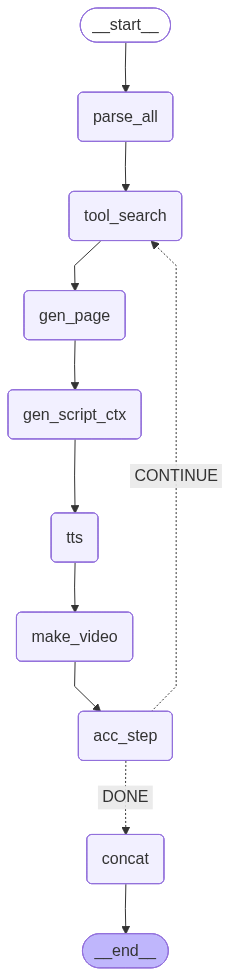

In [ ]:
from langgraph.graph import StateGraph, END

builder = StateGraph(State)

builder.add_node("parse_all", node_parse_all)
builder.add_node("tool_search", node_tool_search)
builder.add_node("gen_page", node_generate_page_content)
builder.add_node("gen_script_ctx", node_generate_script_with_context)
builder.add_node("tts", node_tts)
builder.add_node("make_video", node_make_video)
builder.add_node("acc_step", node_accumulate_and_step)
builder.add_node("concat", node_concat)

builder.set_entry_point("parse_all")

builder.add_edge("parse_all", "tool_search")
builder.add_edge("tool_search", "gen_page")
builder.add_edge("gen_page", "gen_script_ctx")
builder.add_edge("gen_script_ctx", "tts")
builder.add_edge("tts", "make_video")
builder.add_edge("make_video", "acc_step")

builder.add_conditional_edges(
    "acc_step",
    router_continue_or_done,
    {"DONE": "concat", "CONTINUE": "tool_search"},
)

builder.add_edge("concat", END)

app = builder.compile()

In [ ]:
from IPython.display import Image, display

# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

## **4. 시스템 실행**

미션3,4에서 수행한 결과를 통합 테스트 해 봅시다.

### (1) 준비 작업
* 파일 업로드
* 사용자 프롬프트 준비

In [ ]:
# 파일 업로드
uploaded = files.upload()

if uploaded:
    pptx_path = list(uploaded.keys())[0]
    print(f"✅ PPT 업로드 성공: {pptx_path}")
else:
    pptx_path = None
    print("❌ PPT 업로드가 취소되었거나 실패했습니다.")

In [ ]:
import os, datetime

# 사용자 프롬프트(톤/스타일/보이스)
USER_PROMPT = {
    "tone":  "전문적이고 설득력 있는 어조",
    "style": "예시와 핵심 요점 중심",
    "voice": "alloy",   # node_tts에서 tone→voice 매핑 있어도 기본값은 있어야 안전
}

# 출력 디렉터리 만들기
run_id = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
WORK_DIR = f"run_{run_id}"
os.makedirs(WORK_DIR, exist_ok=True)

# (선호) 하위 폴더도 미리 만들어두면 보기 편함
for sub in ["scripts", "tts", "videos"]:
    os.makedirs(os.path.join(WORK_DIR, sub), exist_ok=True)
print(f"📂 작업 디렉터리: {WORK_DIR}")

### (2) Agent 실행
* State 초기화
* app 실행
    * 실행 시, 잘못된 반복 실행이 발생될 수 있으므로 다음 옵션 적용
        * `app.invoke(state, config={"recursion_limit": 100})`
        * 숫자 100은 조정 가능
* 동영상 play

In [ ]:
# 초기 state (dict)
state = {
    "pptx_path": pptx_path,
    "work_dir": WORK_DIR,
    "slide_index": 0,
    "all_scripts": [],
    "prompt": USER_PROMPT,
    # "total_slides": N  # 필요 시 사전 지정, 보통 parse_all이 채움
}

In [ ]:
state.update({
    "slide_index": 0,
    "DONE": False,
    "all_scripts": []   # 이전 누적 스크립트가 남아있으면 문맥이 꼬일 수 있어요
})

In [ ]:
final_state = app.invoke(state, config={"recursion_limit": 100})
print("✅ LangGraph 파이프라인 완료")

In [ ]:
# 1) state에서 스크립트 모으기
scripts = final_state.get("all_scripts") or []
if not scripts:
    # 혹시 all_scripts가 비어있으면 슬라이드에서 직접 긁어옴
    scripts = [(s.get("script") or "").strip() for s in final_state.get("slides", [])]

# 2) 콘솔에 출력
for i, sc in enumerate(scripts, 1):
    print(f"\n==== [Slide {i:02d}] ====\n{sc}\n")

# 3) 하나의 파일로 저장
import os, io
work_dir = final_state.get("work_dir", "./outputs")
script_dir = os.path.join(work_dir, "scripts")
os.makedirs(script_dir, exist_ok=True)

bundle_path = os.path.join(script_dir, "SCRIPTS_ALL.txt")
with open(bundle_path, "w", encoding="utf-8") as f:
    for i, sc in enumerate(scripts, 1):
        f.write(f"[Slide {i:02d}]\n{sc}\n\n")
print(f"[저장] 전체 스크립트: {bundle_path}")

In [ ]:
from IPython.display import Video, display
with open(final_state["final_video"], "rb") as f:
    data = f.read()
display(Video(data=data, embed=True, mimetype="video/mp4", width=960))

## **5. Web APP 개발(Gradio)**
* 화면 개발
    * 입력 : ppt파일, 프롬프트(강의 작성톤), voice 선택(alloy, ...)
    * 출력 : 동영상 play, 동영상 다운로드 버튼
* 기본 화면을 제공합니다. 필요한 기능을 직접 추가하세요.

In [ ]:
import os, time, shutil
import gradio as gr

VOICES = ["alloy", "aria", "verse", "shimmer", "coral", "sage", "tenor", "nova", "amber"]

def run_pipeline_ui(pptx_file, tone, voice):

    # 작업 디렉터리 & 업로드 저장
    work_dir = os.path.join("./webio", f"run-{int(time.time())}")
    os.makedirs(work_dir, exist_ok=True)
    pptx_path = os.path.join(work_dir, "input.pptx")
    shutil.copy(pptx_file.name, pptx_path)

    # 초기 state (State 스키마에 맞춤)
    state = {
        "pptx_path": pptx_path,
        "work_dir": work_dir,
        "prompt": {
            "voice": voice or "alloy",
            "tone":  tone or "친절하고 명료한 강의 톤",
            "style": "예시와 핵심 요점 중심",
        },
    }

    # 그래프 실행
    try:
        final_state = app.invoke(state, config={"recursion_limit": 100})
        video_path = final_state.get("final_video")
        return video_path, video_path

    except Exception as e:
        # 비디오 아웃풋 자리에 None, 다운로드도 None을 주고
        # 대신 콘솔에는 스택트레이스가 찍히게
        import traceback; traceback.print_exc()
        # Gradio가 타입 불일치로 또 오류내지 않게 튜플 형식 유지
        return None, None

# -------------------- Gradio UI --------------------
with gr.Blocks(title="AI 강사 Agent") as demo:
    gr.Markdown("### PPT → 강의영상 자동 제작")

    with gr.Row():
        inp_ppt = gr.File(label="PPTX 업로드", file_types=[".pptx"])
        with gr.Column():
            inp_tone  = gr.Textbox(value="친절하고 명료한 강의 톤", label="강의 작성 톤 (프롬프트)")
            inp_voice = gr.Dropdown(VOICES, value="alloy", label="TTS Voice")

    run_btn = gr.Button("실행", variant="primary")

    out_video    = gr.Video(label="최종 동영상 미리보기", interactive=False)
    out_download = gr.DownloadButton(label="동영상 다운로드")

    run_btn.click(run_pipeline_ui, [inp_ppt, inp_tone, inp_voice], [out_video, out_download])

demo.launch()